# Week 1 POC: Google Trends as a temporal backbone

This notebook tests whether four named Philippine trends produce useful time-series signals. It only collects, stores, describes, and plots Google Trends data. Each series runs from its registered start date through the day this notebook is executed.

Out of scope: social-media scraping, NLP, annotation, sentiment, sarcasm, forecasting, and lifecycle modeling.

In [1]:
# First code cell: small pytrends connectivity/rate-limit smoke test.
from datetime import date, timedelta

PYTRENDS_OK = False
PYTRENDS_STATUS = "not run"
try:
    from pytrends.request import TrendReq

    end = date.today()
    start = end - timedelta(days=30)
    test = TrendReq(hl="en-PH", tz=480, timeout=(10, 20))
    test.build_payload(["Sana All"], timeframe=f"{start} {end}", geo="PH")
    PYTRENDS_OK = not test.interest_over_time().empty
    PYTRENDS_STATUS = "available" if PYTRENDS_OK else "empty response"
except Exception as exc:
    PYTRENDS_STATUS = f"unavailable: {type(exc).__name__}: {exc}"

print(PYTRENDS_STATUS)

available


## Trend registry

**Sana All.** No verified single origin post was found. It is treated as a catchphrase that spread through Philippine social media around **2019**, while the data window begins in 2018 to capture any lead-in. Known forms include “sana all,” “sanaol,” and “naol,” but this POC queries only **Sana All**. Sources: [2019 usage](https://www.sunstar.com.ph/pampanga/opinion/de-leon-new-internet-slang-words-to-know-now) and [variant spellings](https://en.wiktionary.org/wiki/sana_all).

**Pabebe Girls.** Contemporary reports place the viral “Pabebe Warriors” videos by Janet Ricabo and Michelle Alfonso in **July 2015**, not 2013. Known forms include “Pabebe Girls,” “Pabebe Girl,” and “Pabebe Warriors”; this POC queries only **Pabebe Girls**. Source: [GMA, 17 July 2015](https://www.gmanetwork.com/news/hashtag/content/524218/pabebe-warriors-viral-video-was-just-for-laughs/story/).

**Never Grow Old.** Per the researcher’s confirmation, this refers to the TikTok channel/content associated with the prompt **“pwede magtanong?”** The exact first upload is not claimed here; public attention is treated as emerging in early **September 2026**. This POC queries only **Never Grow Old**.

**Fox Silica.** The meme came from Vice President Sara Duterte’s “Fox Silic(a)” rendering of the **Pax Silica** technology initiative. The exchange went viral around **29–31 July 2026** and continued into August. This POC queries only **Fox Silica**. Source: [Philstar, 30 July 2026](https://www.philstar.com/headlines/2026/07/30/2545728/fox-silic-sara-cant-comment-planned-ai-hub).

In [2]:
import csv
import io
import json
import time
from datetime import date, datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

GEO = "PH"
REFRESH = False
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

TODAY = date.today().isoformat()
TRENDS = {
    "sana_all": ("Sana All", f"2018-01-01 {TODAY}"),
    "pabebe_girls": ("Pabebe Girls", f"2015-01-01 {TODAY}"),
    "never_grow_old": ("Never Grow Old", f"2026-08-15 {TODAY}"),
    "fox_silica": ("Fox Silica", f"2026-07-15 {TODAY}"),
}

pd.DataFrame(
    [
        {"trend/query": query, "geo": GEO, "window": window}
        for query, window in TRENDS.values()
    ]
)

,trend/query,geo,window
0,Sana All,PH,2018-01-01 2026-09-15
1,Pabebe Girls,PH,2015-01-01 2026-09-15
2,Never Grow Old,PH,2026-08-15 2026-09-15
3,Fox Silica,PH,2026-07-15 2026-09-15


## Data collection

The notebook first uses a saved raw file, then `pytrends`, then a manual export. For manual fallback, export **Interest over time** from Google Trends with the matching query, Philippines geography, and date window; save it as `data/<slug>.csv`, such as `data/fox_silica.csv`.

Automated pulls retry HTTP 429 responses with backoff. Every result is saved to `data/raw/<slug>.csv` with a JSON file containing the query, window, geography, source, and extraction time.

In [3]:
def load_manual_csv(path):
    # Load a Google Trends Interest-over-time CSV.
    lines = Path(path).read_text(encoding="utf-8-sig").splitlines()
    header = next(
        i
        for i, line in enumerate(lines)
        if line.split(",", 1)[0].strip().lower() in {"date", "day", "week", "month"}
    )
    frame = pd.read_csv(io.StringIO("\n".join(lines[header:])))
    frame = frame.rename(columns={frame.columns[0]: "date"})
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce")
    frame = frame.dropna(subset=["date"]).set_index("date")

    value_columns = list(frame.columns)
    if len(value_columns) != 1:
        raise ValueError("Manual CSV must contain exactly one query series.")
    frame.columns = [frame.columns[0].split(":", 1)[0].strip()]
    frame.iloc[:, 0] = pd.to_numeric(
        frame.iloc[:, 0].astype(str).str.strip().replace({"<1": "0.5", "< 1": "0.5"}),
        errors="coerce",
    )
    return frame


def pull_pytrends(query, window, attempts=4):
    for attempt in range(attempts):
        try:
            client = TrendReq(hl="en-PH", tz=480, timeout=(10, 30))
            client.build_payload([query], timeframe=window, geo=GEO)
            frame = client.interest_over_time().drop(columns="isPartial", errors="ignore")
            if frame.empty:
                raise RuntimeError("empty Google Trends response")
            return frame
        except Exception as exc:
            status = getattr(getattr(exc, "response", None), "status_code", None)
            if status != 429 or attempt == attempts - 1:
                raise
            delay = 2 ** attempt
            print(f"HTTP 429; retrying in {delay}s")
            time.sleep(delay)


def save_result(slug, frame, metadata):
    frame.rename_axis("date").to_csv(RAW_DIR / f"{slug}.csv")
    (RAW_DIR / f"{slug}.json").write_text(
        json.dumps(metadata, indent=2), encoding="utf-8"
    )


def acquire(slug, query, window):
    raw_csv = RAW_DIR / f"{slug}.csv"
    raw_json = RAW_DIR / f"{slug}.json"
    if raw_csv.exists() and raw_json.exists() and not REFRESH:
        frame = pd.read_csv(raw_csv, parse_dates=["date"]).set_index("date")
        return frame, json.loads(raw_json.read_text(encoding="utf-8"))

    source = "pytrends"
    try:
        if not PYTRENDS_OK:
            raise RuntimeError(PYTRENDS_STATUS)
        frame = pull_pytrends(query, window)
    except Exception as automated_error:
        manual_path = DATA_DIR / f"{slug}.csv"
        if not manual_path.exists():
            raise RuntimeError(
                f"pytrends failed for {query}: {automated_error}. "
                f"Add the manual export at {manual_path}."
            )
        frame = load_manual_csv(manual_path)
        source = "manual Google Trends CSV"

    metadata = {
        "query": query,
        "geo": GEO,
        "window": window,
        "source": source,
        "extracted_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    }
    save_result(slug, frame, metadata)
    return frame, metadata

In [4]:
data = {}
metadata = {}

for slug, (query, window) in TRENDS.items():
    data[slug], metadata[slug] = acquire(slug, query, window)
    print(f"{query}: {len(data[slug])} rows from {metadata[slug]['source']}")
    time.sleep(1)

Sana All: 105 rows from pytrends


Pabebe Girls: 141 rows from pytrends


Never Grow Old: 32 rows from pytrends


Fox Silica: 63 rows from pytrends


In [5]:
def show_trend(slug):
    query, _ = TRENDS[slug]
    frame = data[slug]
    series = frame.iloc[:, 0].dropna()
    positive = series[series > 0]

    if positive.empty:
        description = "All returned values are zero in the selected window."
    else:
        first = positive.index[0]
        peak = series.idxmax()
        last = series.iloc[-1]
        description = (
            f"Interest first appears on **{first:%d %b %Y}**, peaks on "
            f"**{peak:%d %b %Y}**, and ends at **{last:g}**. "
            "This describes the search series, not the trend's proven origin."
        )
    display(Markdown(description))

    fig, ax = plt.subplots(figsize=(9, 3.5))
    series.plot(ax=ax, linewidth=2, color="#2463a6")
    ax.set(title=f"{query} — Philippines", xlabel="Date", ylabel="Interest (0–100)")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

## Sana All

Interest first appears on **01 Jan 2018**, peaks on **01 Nov 2019**, and ends at **5**. This describes the search series, not the trend's proven origin.

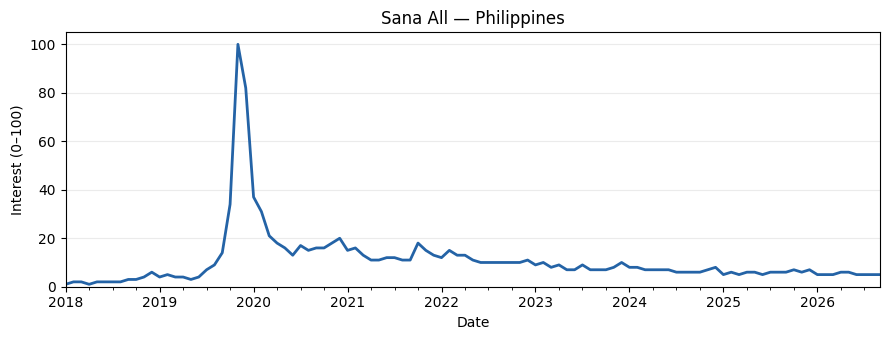

In [6]:
show_trend("sana_all")

## Pabebe Girls

Interest first appears on **01 Jun 2015**, peaks on **01 Jul 2015**, and ends at **0**. This describes the search series, not the trend's proven origin.

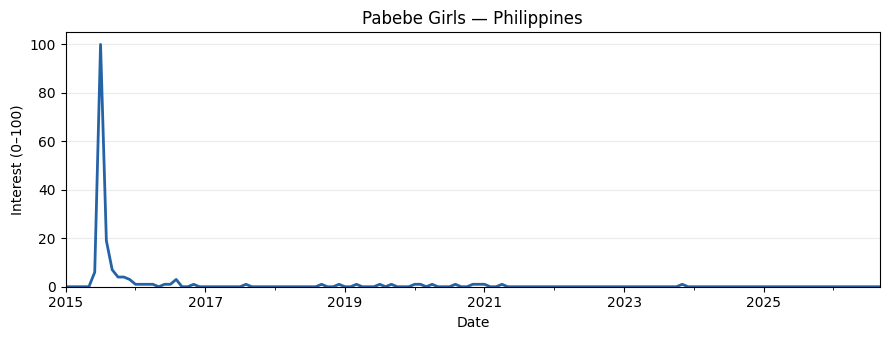

In [7]:
show_trend("pabebe_girls")

## Never Grow Old

Interest first appears on **01 Sep 2026**, peaks on **10 Sep 2026**, and ends at **39**. This describes the search series, not the trend's proven origin.

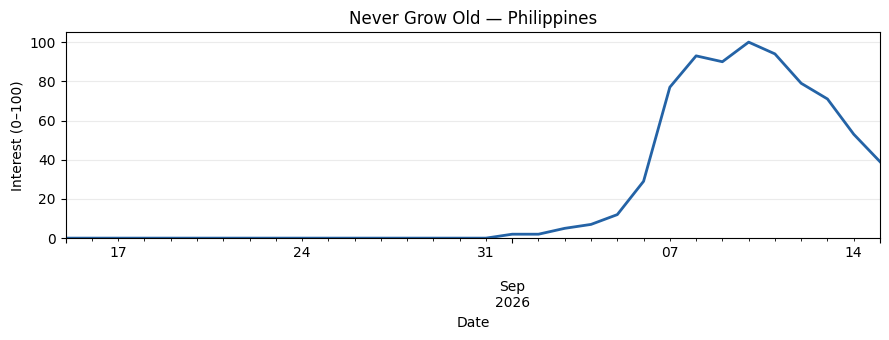

In [8]:
show_trend("never_grow_old")

## Fox Silica

Interest first appears on **29 Jul 2026**, peaks on **29 Jul 2026**, and ends at **0**. This describes the search series, not the trend's proven origin.

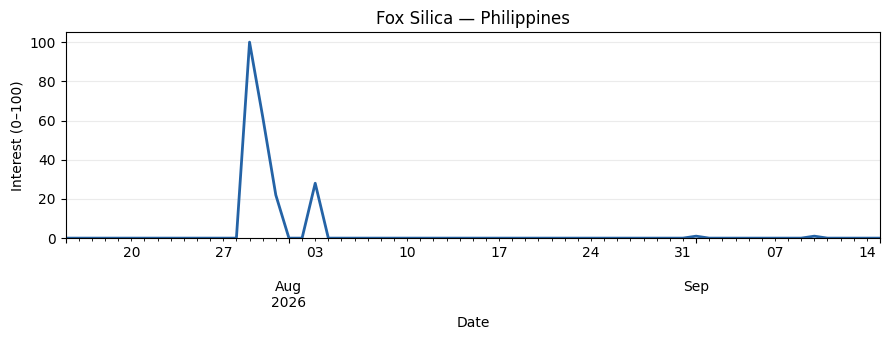

In [9]:
show_trend("fox_silica")

## Limitations

Google Trends values are relative 0–100 scores, not search counts, and each query/window is normalized separately. The long start-to-now histories returned monthly values, while the short 2026 windows returned daily values, so plot resolution differs. Searches can reflect news or unrelated meanings, especially the generic phrase “Never Grow Old.” Rerunning through a later date can rescale earlier 0–100 values. Google Trends is therefore a timing signal, not proof of origin or total social-media attention.